In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset

In [2]:
from sklearn import datasets

In [3]:
dataset_type = 'anisotropic_gaussian'

def random_covariance_gaussian(n_samples, n_features,cov,random_state=None):

    mean = np.zeros(n_features)
    rng = np.random.default_rng(seed=random_state)
    return rng.multivariate_normal(mean, cov,size=n_samples)

In [4]:
n_samples = 1000
n_features = 10
seed = 42

cov = datasets.make_spd_matrix(n_dim=n_features, random_state=seed)
X = random_covariance_gaussian(n_samples,n_features,cov,seed)

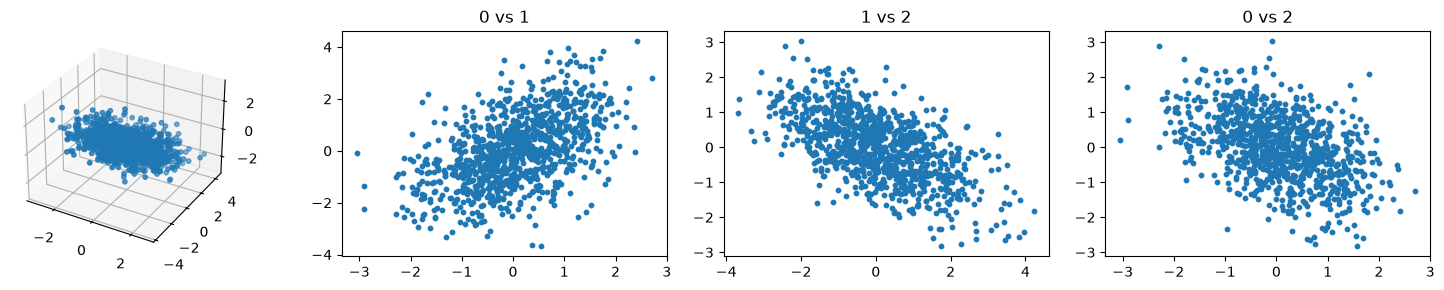

In [5]:
plot_3d_scatters(X,'',y=None)

In [6]:
# generate a list of random seeds to use for saving data

# rng = np.random.default_rng(42)
# num_seeds = 10
# random_seeds_lst = rng.integers(0, 2**20, size=num_seeds).tolist()

random_seeds_lst = [42,980]

In [7]:
# delete_dataset('anisotropic_gaussian','../all_data/')

In [8]:
data_gen_name = 'anisotropic_gaussian'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000]

# --- generate cov matrices ---
# currently randomly generated for each feature, but can be varied
random_seeds_cov = [56,1000] #corresponding to each random seed for data generating, we have a random seed to generate the covariance matrix
assert len(random_seeds_lst) == len(random_seeds_cov)
feature_covs_dict = {  (n_features,seed) : datasets.make_spd_matrix(n_dim=n_features, random_state=seed) for n_features, seed in product(n_features_lst,random_seeds_cov)}

# data save loop
for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features, X.shape)

    for sample_num,seed in enumerate(random_seeds_lst):
        
        cov_seed = random_seeds_cov[sample_num] #different from the data gen seed to avoid correlations
        cov = feature_covs_dict[(n_features,cov_seed)]
        X = random_covariance_gaussian(n_samples,n_features,cov,seed)
        
        params_dict = {
            'cov data gen method' : f'gen using sklearn datasets .make_spd_matrix',
            'n_dim' : n_features,
            'random_state' : cov_seed
        }
        
        try:
            save_dataset(X, 
                        generator=data_gen_name,
                        params=params_dict,
                        seed=seed,
                        category=category_lst,
                        extra_arrays={'cov' : cov}, 
                        root='../all_data/')

        except:
            print('file already exists')

1000 10 (1000, 10)
1000 100 (1000, 10)
1000 1000 (1000, 100)
10000 10 (1000, 1000)
10000 100 (10000, 10)
10000 1000 (10000, 100)


for P = 10000 can consider generating cov matrix in a different way??
because .make_spd_matrix takes 10-40mins to generate one

## plots

In [15]:
m = pd.read_csv("../all_data/manifest.csv")
generator = 'anisotropic_gaussian'
m = m[(m.generator == generator)]
m

,dataset_id,generator,category,n_rows,n_cols,params_id,seed,extra_files
64,anisotropic_gaussian/params0/seed42_N1000_P10,anisotropic_gaussian,['density'],1000,10,params0,42,"[""cov_seed42.npy""]"
65,anisotropic_gaussian/params1/seed980_N1000_P10,anisotropic_gaussian,['density'],1000,10,params1,980,"[""cov_seed980.npy""]"
66,anisotropic_gaussian/params2/seed42_N1000_P100,anisotropic_gaussian,['density'],1000,100,params2,42,"[""cov_seed42.npy""]"
67,anisotropic_gaussian/params3/seed980_N1000_P100,anisotropic_gaussian,['density'],1000,100,params3,980,"[""cov_seed980.npy""]"
68,anisotropic_gaussian/params4/seed42_N1000_P1000,anisotropic_gaussian,['density'],1000,1000,params4,42,"[""cov_seed42.npy""]"
69,anisotropic_gaussian/params5/seed980_N1000_P1000,anisotropic_gaussian,['density'],1000,1000,params5,980,"[""cov_seed980.npy""]"
70,anisotropic_gaussian/params0/seed42_N10000_P10,anisotropic_gaussian,['density'],10000,10,params0,42,"[""cov_seed42.npy""]"
71,anisotropic_gaussian/params1/seed980_N10000_P10,anisotropic_gaussian,['density'],10000,10,params1,980,"[""cov_seed980.npy""]"
72,anisotropic_gaussian/params2/seed42_N10000_P100,anisotropic_gaussian,['density'],10000,100,params2,42,"[""cov_seed42.npy""]"
73,anisotropic_gaussian/params3/seed980_N10000_P100,anisotropic_gaussian,['density'],10000,100,params3,980,"[""cov_seed980.npy""]"


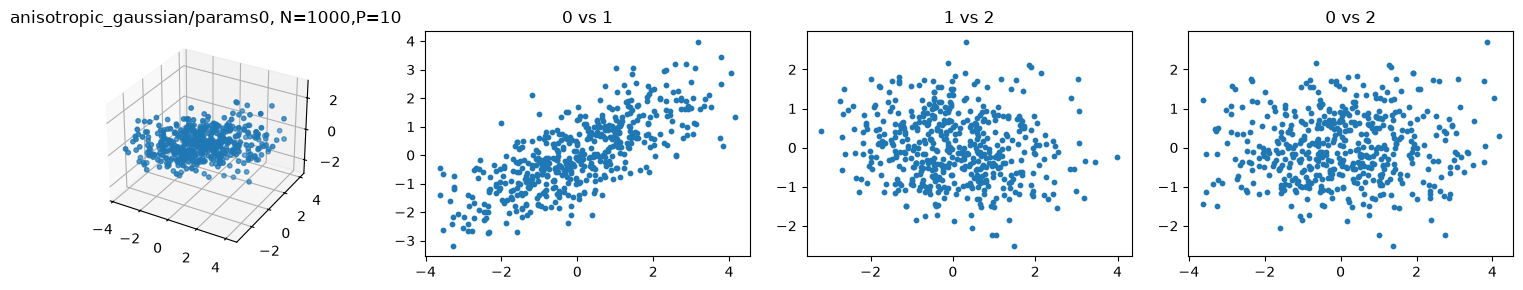

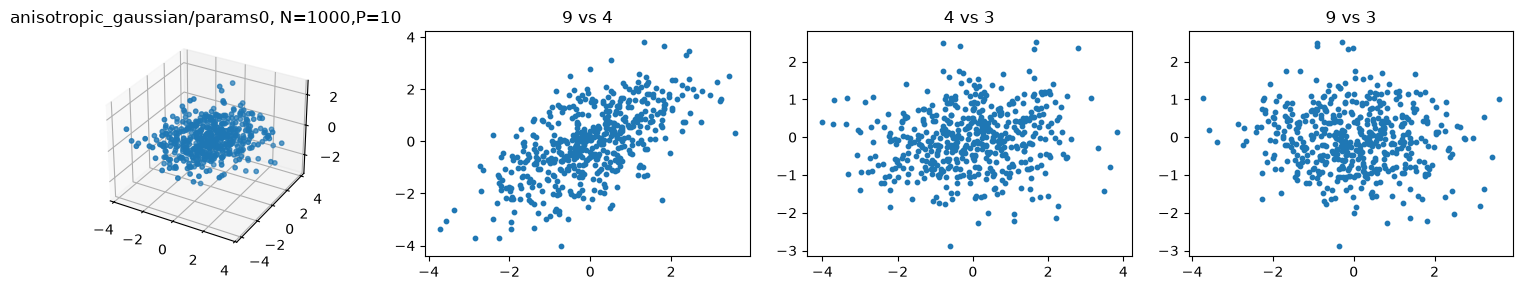

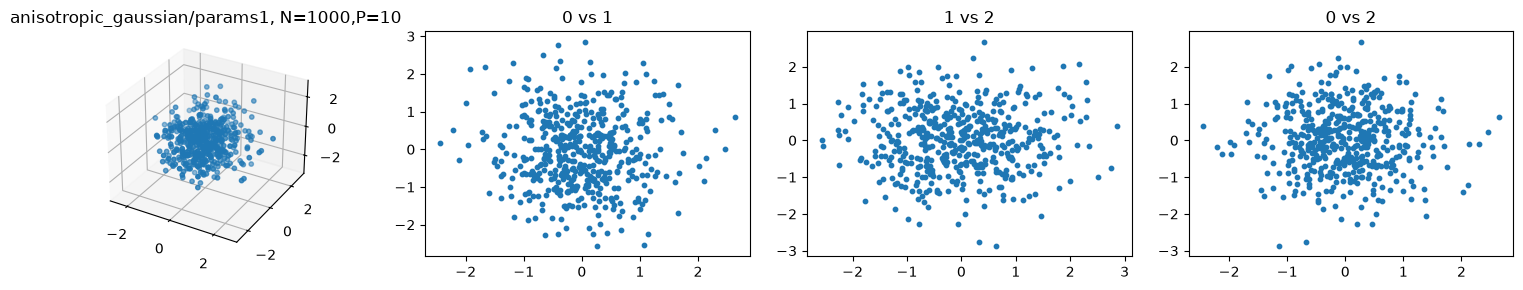

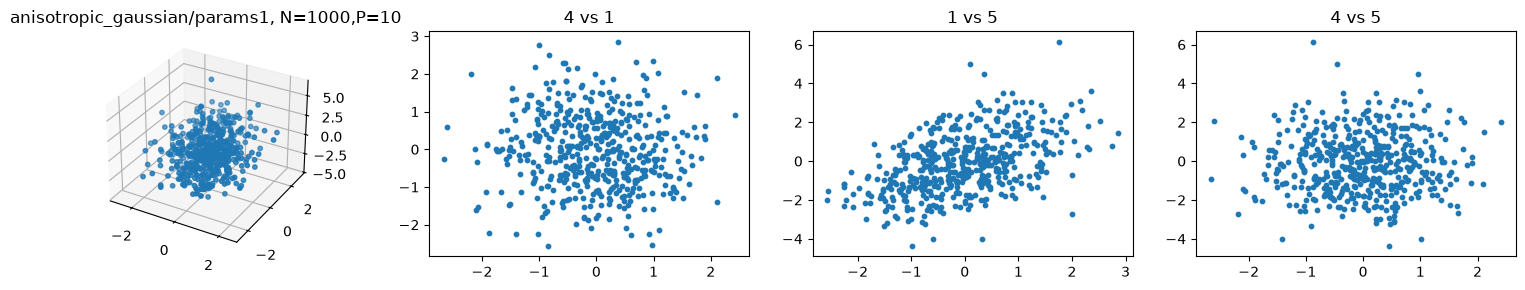

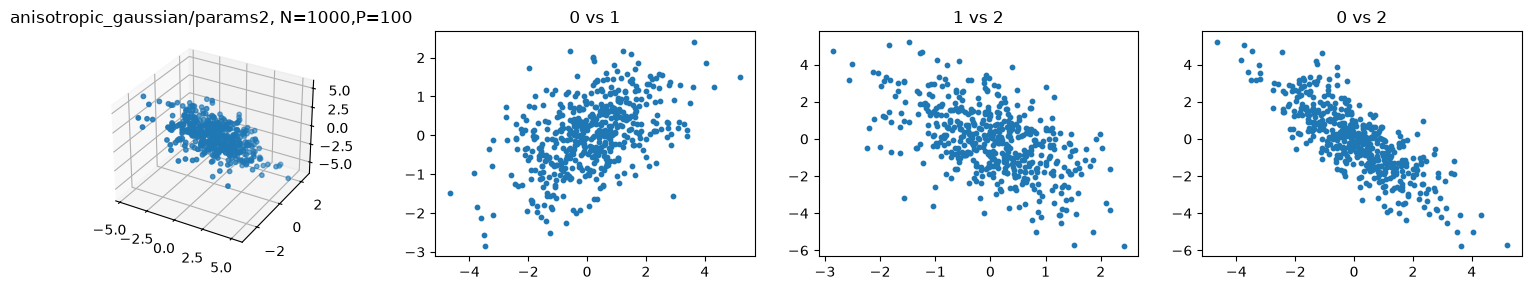

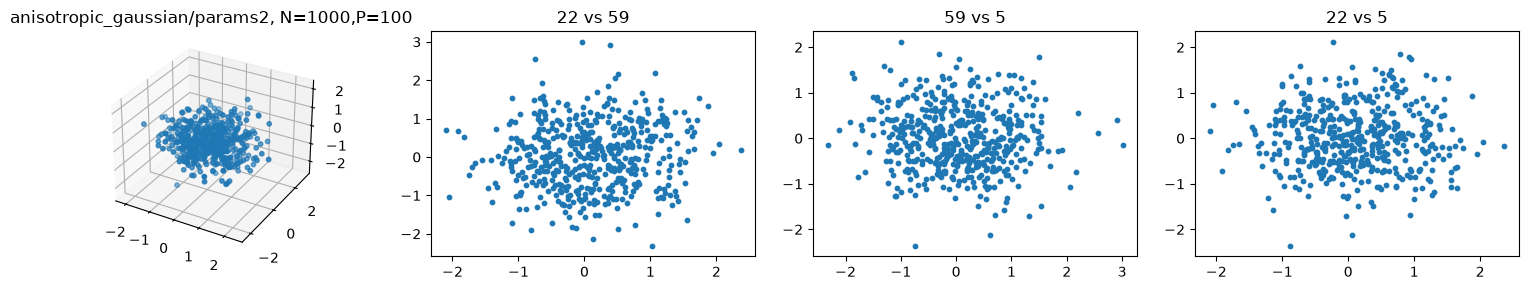

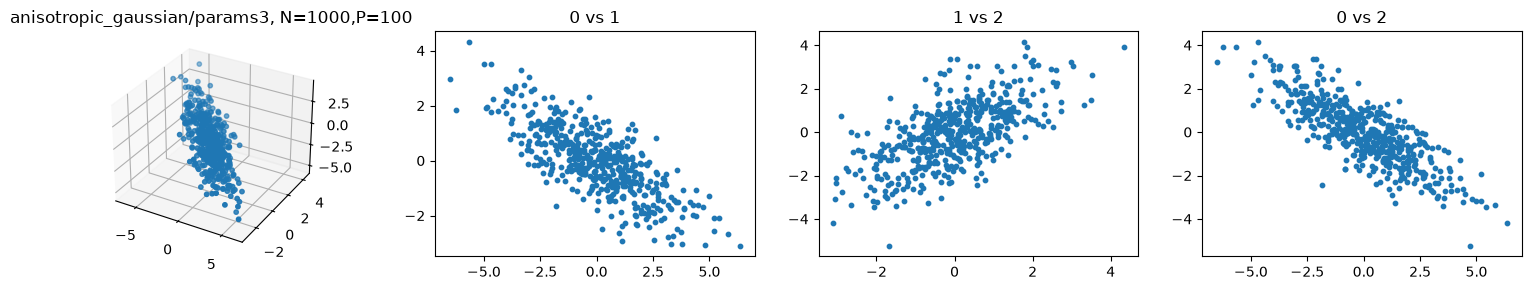

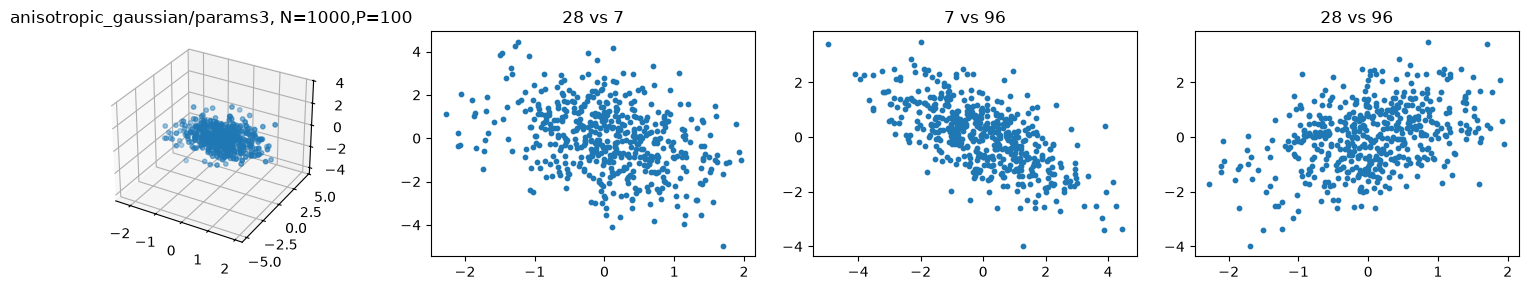

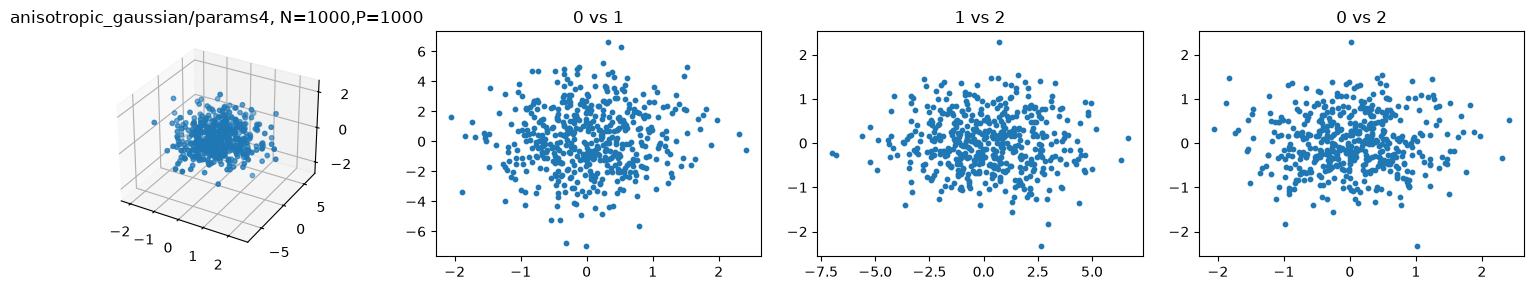

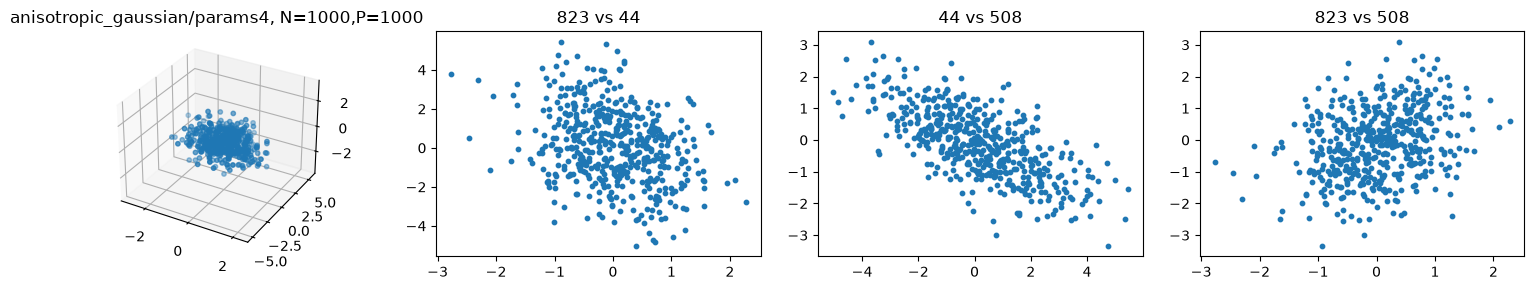

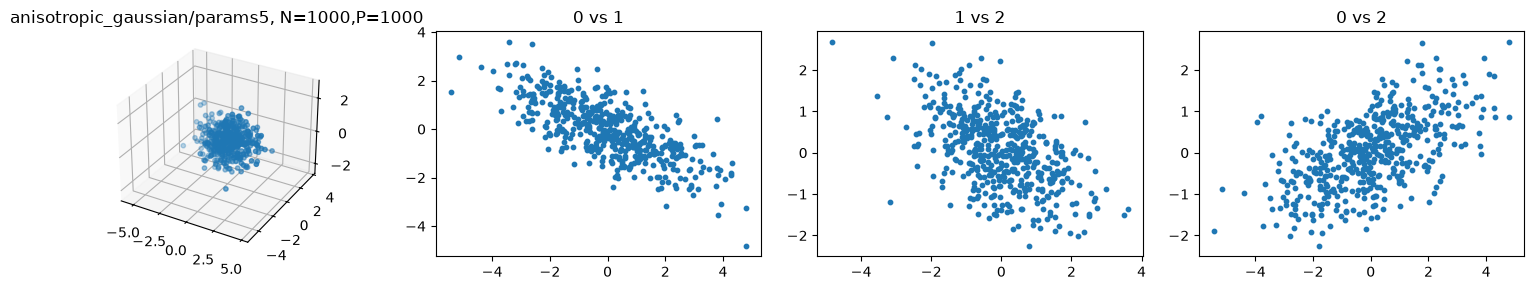

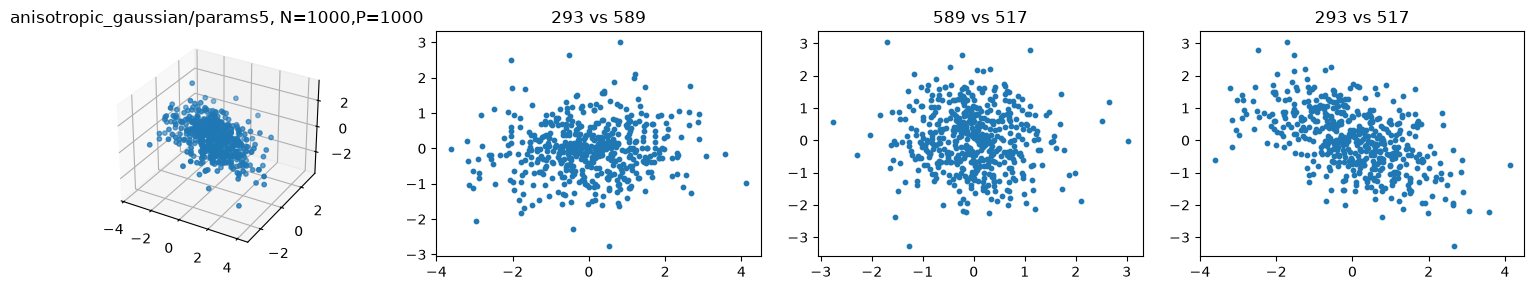

In [26]:
max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(1).itertuples():
    X = np.load(Path('../all_data/')  / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}")
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}",custom_inx=np.random.randint(0,r.n_cols,3))

array([10, 23, 17])